In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm, colors
import matplotlib
import seaborn as sns
import numpy as np

In [2]:
excluded_samples=['ST002-1D_LUNG-pacbio-uwsc-group1']

In [3]:
df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

In [4]:

comb_numt_df = pd.DataFrame()

for sample in df_pb['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])

for sample in df_ont['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])


comb_numt_df[['nchr', 'npos']] = comb_numt_df['qseqid'].str.split('-', expand=True)
comb_numt_df['npos'] = np.where(comb_numt_df['qstart'].astype(int) > 1, comb_numt_df['npos'].astype(int) + comb_numt_df['qstart'].astype(int) - 1, comb_numt_df['npos'].astype(int))
comb_numt_df['id'] = comb_numt_df['nchr'] + "-" + comb_numt_df['npos'].astype(str)
comb_numt_df = comb_numt_df[comb_numt_df['nchr'] != 'chrM']
comb_numt_df['mstart'] = np.where(comb_numt_df['sstart'].astype(int) < comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))
comb_numt_df['mend'] = np.where(comb_numt_df['sstart'].astype(int) >= comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))

comb_numt_df = comb_numt_df[['qseqid', 'id', 'nchr', 'npos', 'length', 'mstart', 'mend', 'Sample']]

comb_numt_df[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = comb_numt_df['Sample'].str.split('-', expand=True)
comb_numt_df['Donor+Tissue'] = comb_numt_df['Donor'] + "_" + comb_numt_df['Tissue']

comb_numt_df = comb_numt_df[~(comb_numt_df['Sample'].isin(excluded_samples))]

comb_numt_df


,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue
0,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON
1,chr1-54625173,chr1-54625173,chr1,54625173,41,1573,1613,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON
2,chr2-33667411,chr2-33667416,chr2,33667416,246,14777,15022,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON
3,chr4-86138984,chr4-86138984,chr4,86138984,47,6170,6216,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON
4,chr5-144790242,chr5-144790242,chr5,144790242,329,15178,15506,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,chr5-32338477,chr5-32338624,chr5,32338624,145,12723,12867,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
6,chr11-4635113,chr11-4635113,chr11,4635113,40,16423,16462,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
7,chr11-49862017,chr11-49862017,chr11,49862017,60,1,60,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
8,chr11-100145004,chr11-100145018,chr11,100145018,59,11499,11557,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER


In [5]:
tolerance = 25

df = comb_numt_df.sort_values(
    ['nchr', 'npos', 'mstart', 'mend']
).reset_index(drop=True)

numt_ids = [None] * len(df)
current_id = 1

for i in range(len(df)):
    if numt_ids[i] is not None:
        continue

    numt_ids[i] = f"NUMT_{current_id}"
    current = df.iloc[i]

    # grow cluster forward
    for j in range(i + 1, len(df)):
        row = df.iloc[j]

        if row['nchr'] != current['nchr']:
            break  # sorted by chr

        if abs(row['npos'] - df.loc[i, 'npos']) > tolerance:
            break  # window exceeded

        if (
            abs(row['length'] - current['length']) <= tolerance and
            abs(row['mstart'] - current['mstart']) <= tolerance and
            abs(row['mend'] - current['mend']) <= tolerance
        ):
            numt_ids[j] = f"NUMT_{current_id}"

    current_id += 1

df['NUMT_ID'] = numt_ids

rep_cols = {
    'npos':   'npos_rep',
    'length':'length_rep',
    'mstart':'mstart_rep',
    'mend':  'mend_rep'
}

for col, new_col in rep_cols.items():
    df[new_col] = (
        df.groupby('NUMT_ID')[col]
          .transform('median')
          .astype(int)
    )

df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)


df

,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
0,chr1-37611748,chr1-37611748,chr1,37611748,71,8935,9005,ST002-1G_COLON-ont-uwsc,ST002,1G_COLON,ont,uwsc,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
1,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
2,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
3,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1D_LUNG-pacbio-bcm,ST002,1D_LUNG,pacbio,bcm,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
4,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1D_LUNG-pacbio-washu,ST002,1D_LUNG,pacbio,washu,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-pacbio-broad,ST003,1Q_BRAIN,pacbio,broad,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
363,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-pacbio-uwsc,ST003,1Q_BRAIN,pacbio,uwsc,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
364,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-ont-nygc,ST003,1Q_BRAIN,ont,nygc,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
365,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-ont-uwsc,ST003,1Q_BRAIN,ont,uwsc,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420


In [6]:

high_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) > 1)
high_conf_numts


low_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) == 1)
low_conf_numts

,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
44,chr1-230505699,chr1-230505758,chr1,230505758,1457,2489,3932,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_3,230505758,1457,2489,3932,chr1_230505758_1457_2489_3932
161,chr14-25947180,chr14-25947180,chr14,25947180,38,5781,5818,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_9,25947180,38,5781,5818,chr14_25947180_38_5781_5818
237,chr22-40620124,chr22-40620124,chr22,40620124,1020,3252,4269,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_13,40620124,1020,3252,4269,chr22_40620124_1020_3252_4269
238,chr22-40620124,chr22-40621136,chr22,40621136,1414,3240,4649,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_14,40621136,1414,3240,4649,chr22_40621136_1414_3240_4649
347,chr7-115030581,chr7-115030582,chr7,115030582,5287,3218,8492,ST004-1Q_BRAIN-pacbio-uwsc,ST004,1Q_BRAIN,pacbio,uwsc,None,ST004_1Q_BRAIN,NUMT_20,115030582,5287,3218,8492,chr7_115030582_5287_3218_8492
366,chrX-111421052,chrX-111422220,chrX,111422220,40,3036,3075,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_23,111422220,40,3036,3075,chrX_111422220_40_3036_3075


In [7]:
def custom_join(series):
    return ','.join(series.astype(str))

collapsed_numt_df = high_conf_numts.groupby(['numt_long', 'length_rep', 'Donor', 'Tissue']).agg(
        reps=('numt_long', 'count'), rep_names=('Sample', custom_join)).reset_index()

collapsed_numt_df['Donor_Tissue'] = collapsed_numt_df['Donor'] + "-" + collapsed_numt_df['Tissue']

collapsed_numt_df

,numt_long,length_rep,Donor,Tissue,reps,rep_names,Donor_Tissue
0,chr11_100145018_59_11499_11557,59,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-uwsc,ST001-1A_LIVER-pacb...",ST001-1A_LIVER
1,chr11_100145018_59_11499_11557,59,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG
2,chr11_100145018_59_11499_11557,59,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
3,chr11_100145018_59_11499_11557,59,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",ST002-1G_COLON
4,chr11_4635113_40_16423_16462,40,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-uwsc,ST001-1A_LIVER-pacb...",ST001-1A_LIVER
5,chr11_4635113_40_16423_16462,40,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG
6,chr11_4635113_40_16423_16462,40,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
7,chr11_4635113_40_16423_16462,40,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",ST002-1G_COLON
8,chr11_4635113_40_16423_16462,40,ST003,1Q_BRAIN,6,"ST003-1Q_BRAIN-pacbio-washu,ST003-1Q_BRAIN-pac...",ST003-1Q_BRAIN
9,chr11_4635113_40_16423_16462,40,ST004,1Q_BRAIN,6,"ST004-1Q_BRAIN-pacbio-uwsc,ST004-1Q_BRAIN-pacb...",ST004-1Q_BRAIN


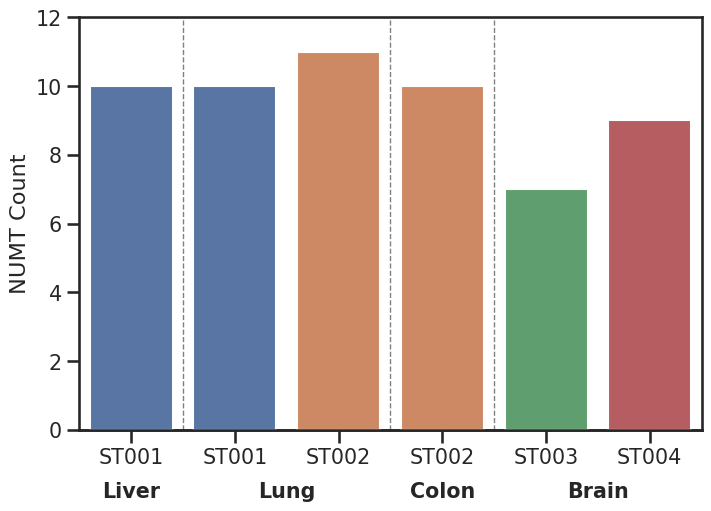

['\n\nLIVER', '\n\nLUNG', '\n\nLUNG', '\n\nCOLON', '\n\nBRAIN', '\n\nBRAIN']


In [8]:
counts = (
    collapsed_numt_df.groupby("Donor_Tissue", as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)
counts[['Donor', 'Tissue']] = counts['Donor_Tissue'].str.split('-', expand=True)

sns.set_theme(style="ticks", context="talk", font_scale=0.9)

fig, ax = plt.subplots(layout='constrained', figsize=(7, 5))

g = sns.barplot(
    data=counts,
    x="Donor_Tissue",
    y="count",
    hue="Donor",
    legend=False,
    ax=ax
)
plt.ylim(0,12)

# Get original tick labels
ticks = ax.get_xticklabels()
labels = [t.get_text() for t in ticks]
donors  = [l.split("-")[0] for l in labels]  
tissues = ['\n\n' + l.split("-")[1].split("_")[1] for l in labels]

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(donors, rotation=0)
ax.set_ylabel("NUMT Count")
ax.set_xlabel("")

sec = ax.secondary_xaxis(location=0)
sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
sec.tick_params('x', length=0)

for tick in sec.get_xticklabels():
    tick.set_fontweight("bold")
    #tick.set_fontsize(14)

midpoints = [0.5,2.5,3.5]
for x in midpoints:
    ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

plt.show()
print(tissues)

In [9]:
collapsed_numt_df[['numt_long', 'length_rep']].drop_duplicates()['length_rep'].median()

66.0

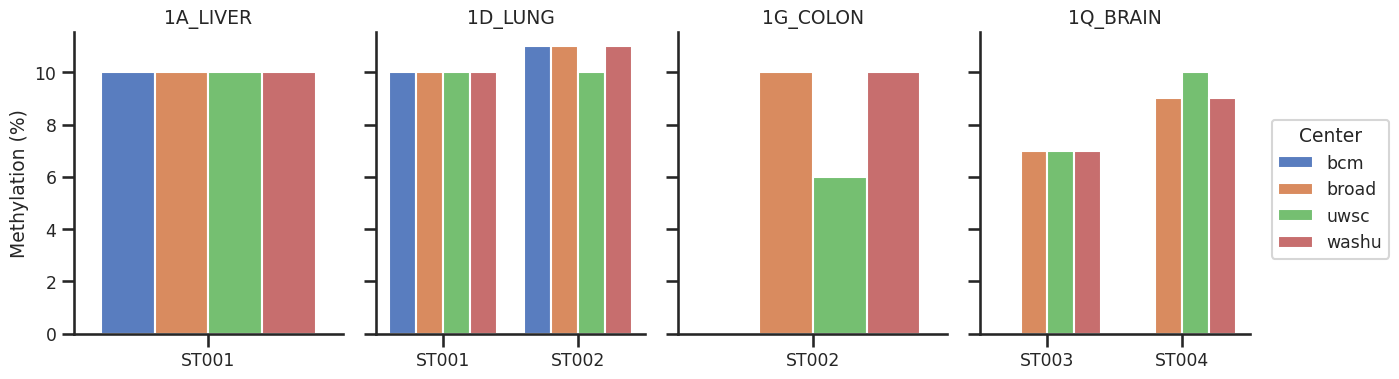

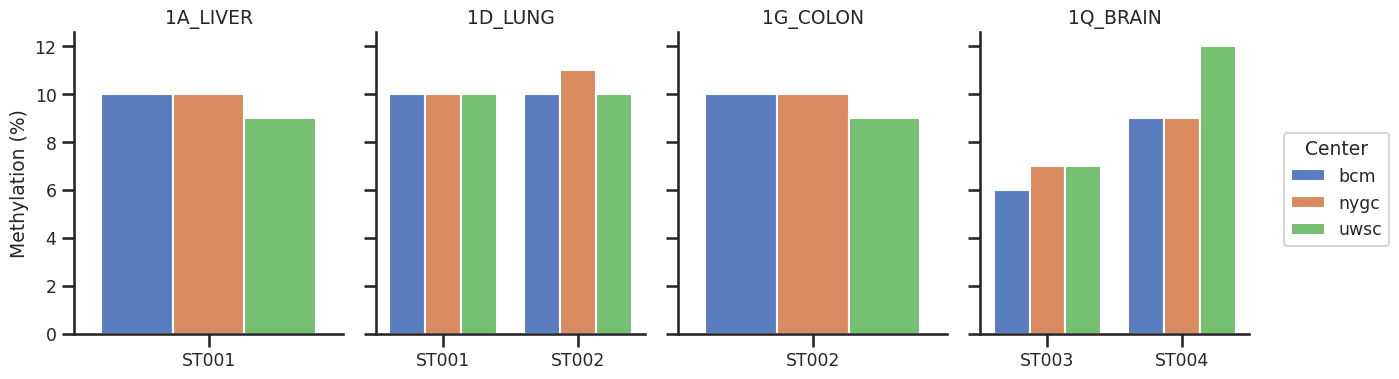

In [10]:
counts_ind = (
    df.groupby("Sample", as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)
counts_ind[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = counts_ind['Sample'].str.split('-', expand=True)
counts_ind['Donor+Tissue'] = counts_ind['Donor'] + "_" + counts_ind['Tissue']

counts_ind

sns.set_theme(style="ticks", context="talk", font_scale=0.75)

g = sns.catplot(
    data=counts_ind[counts_ind['Seq_Tech'] == 'pacbio'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=counts_ind[counts_ind['Seq_Tech'] == 'ont'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

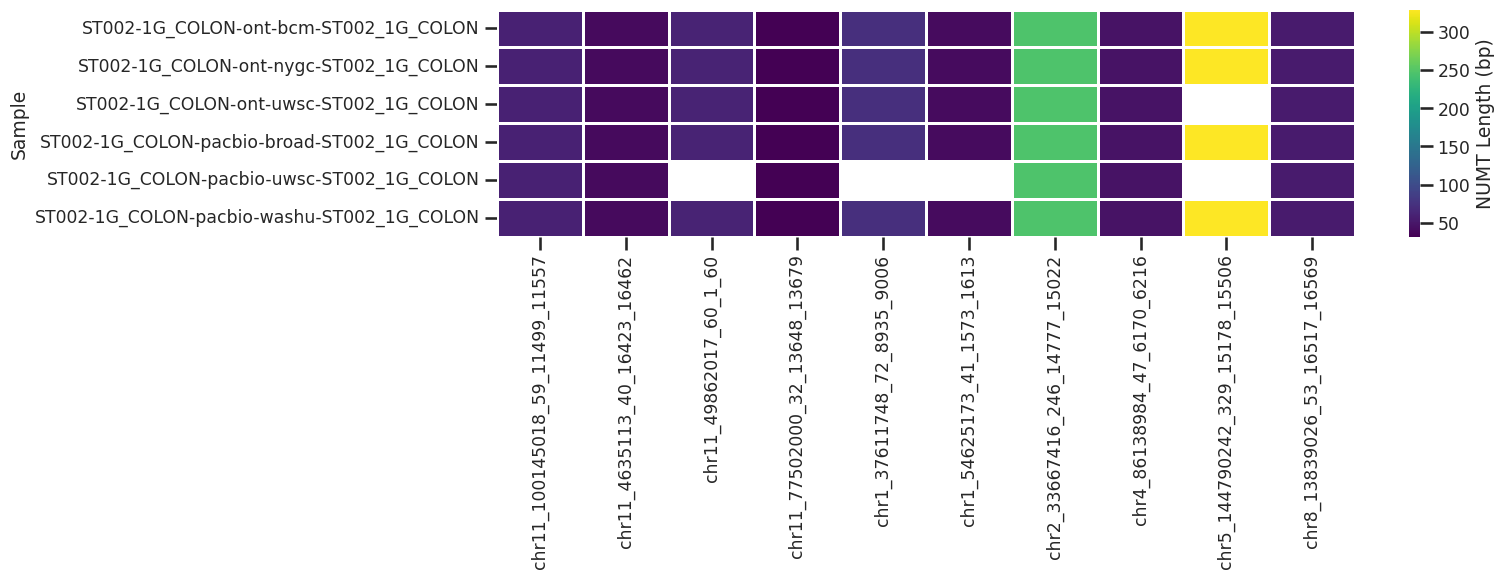

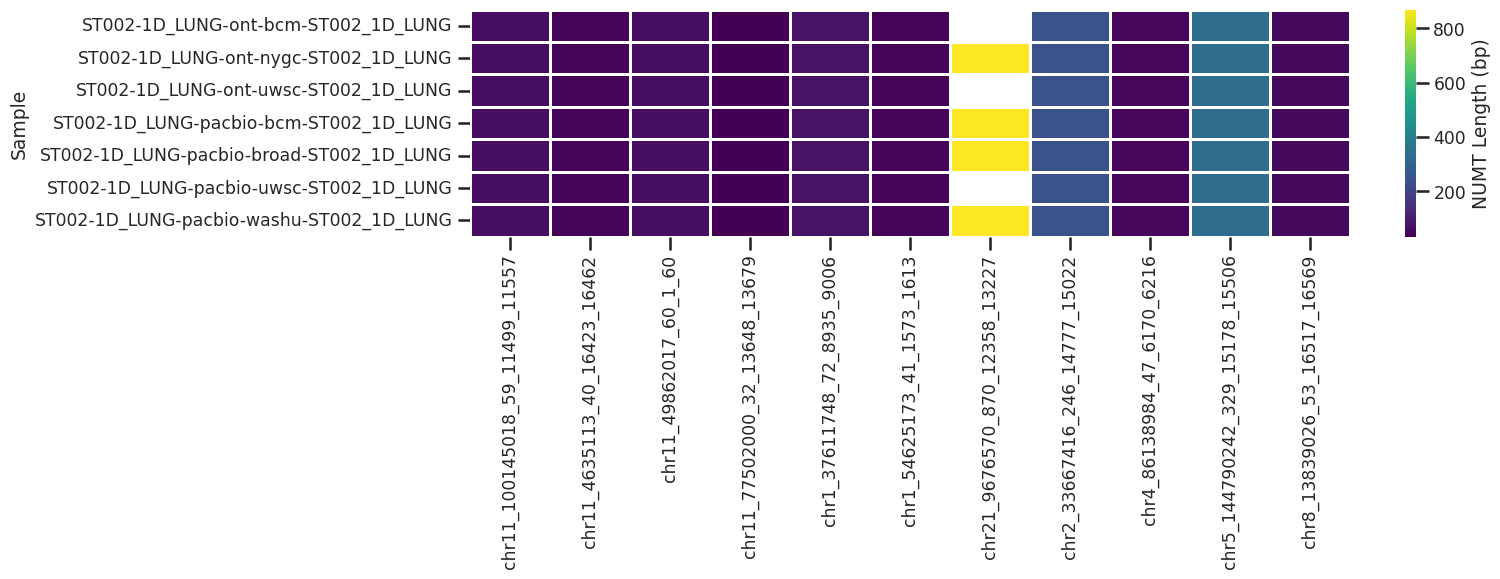

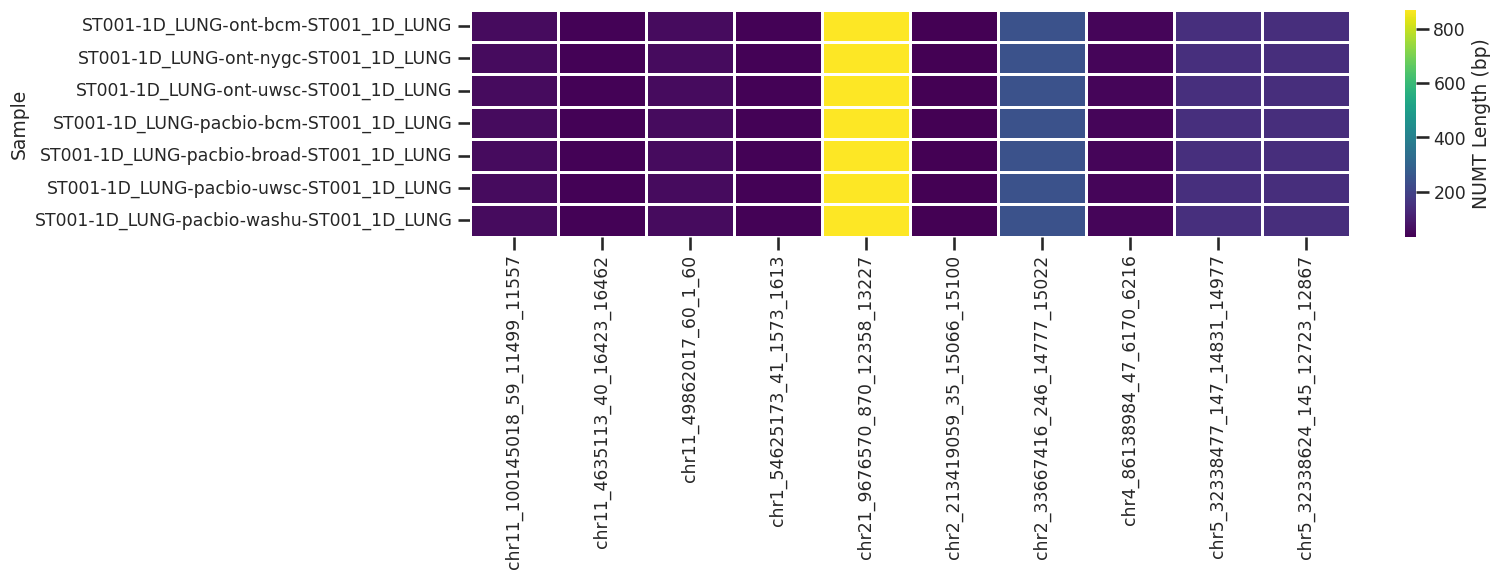

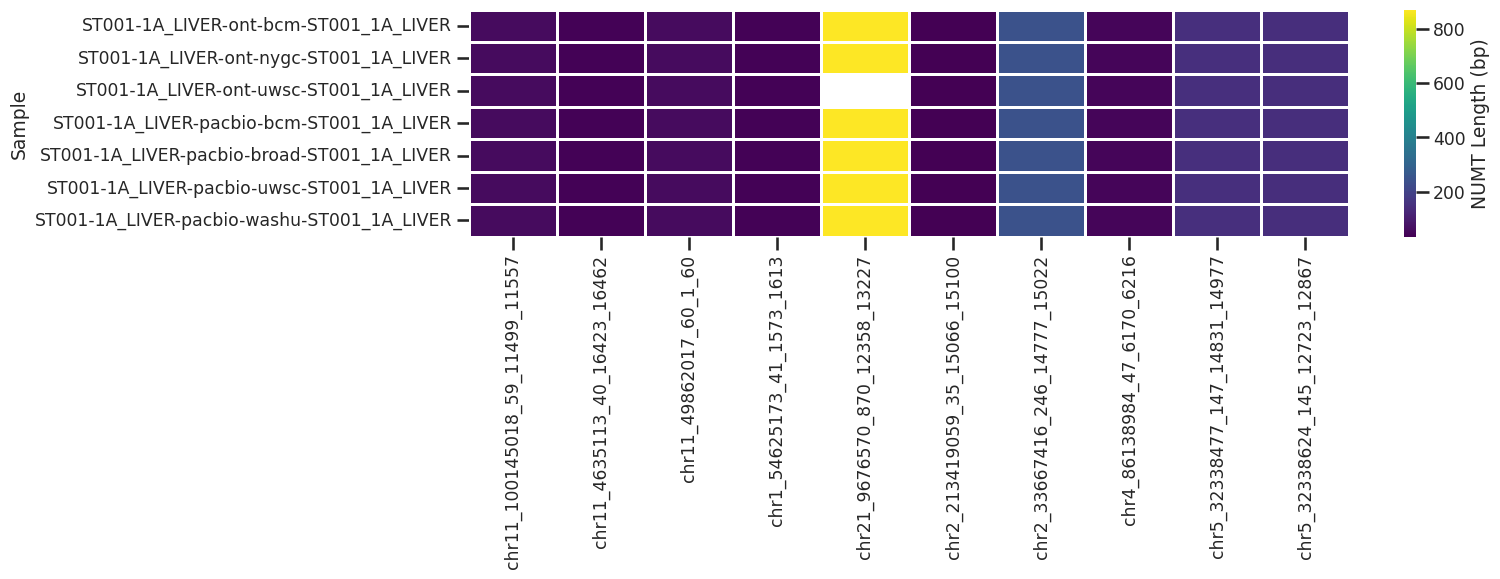

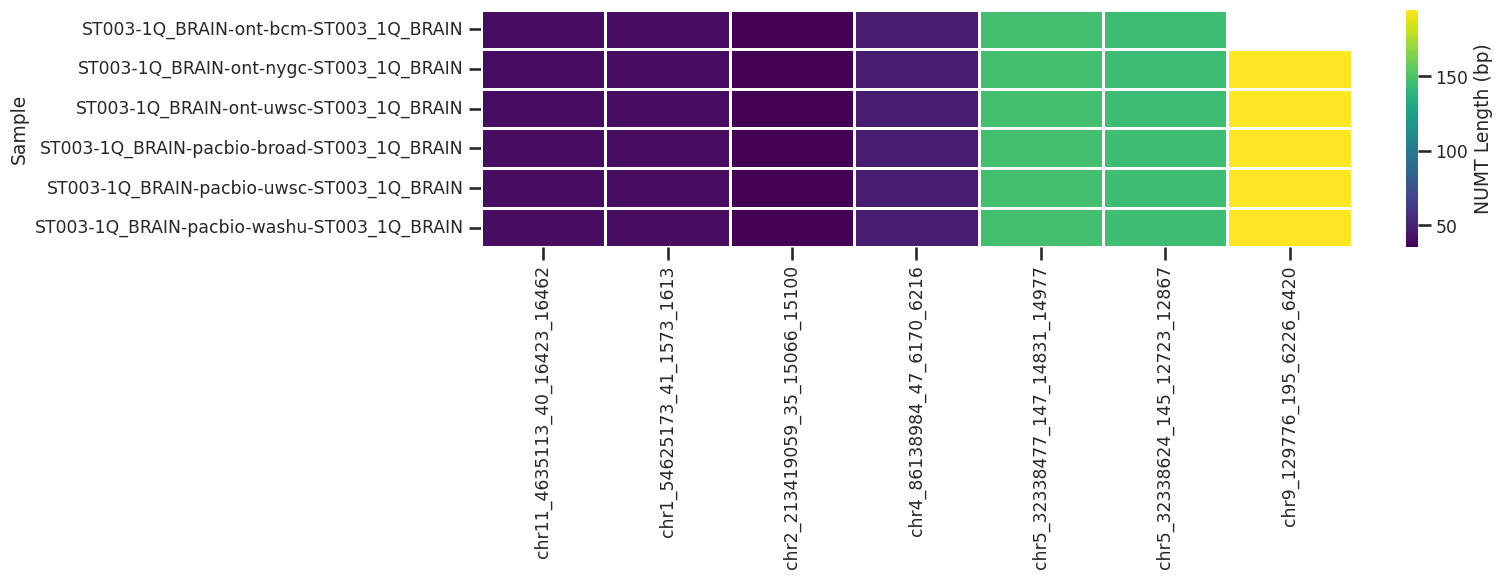

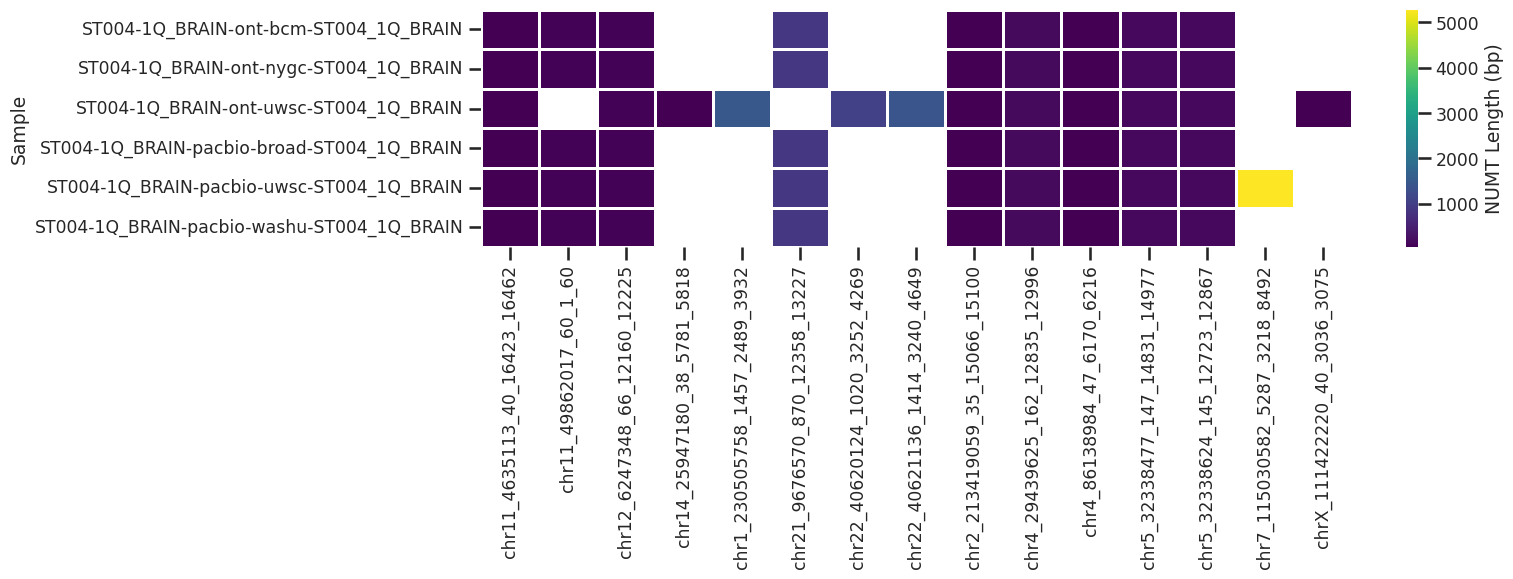

In [11]:

donors = ['ST001', 'ST002', 'ST003', 'ST004']

for d in df['Donor+Tissue'].unique():

    heatmap_data = df[df['Donor+Tissue'] == d].pivot(index=['Sample','Donor+Tissue'], columns='numt_long', values='length_rep')

    # Sort columns by chrom
    #column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    #heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'NUMT Length (bp)'})
    plt.title('')
    plt.xlabel('')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()


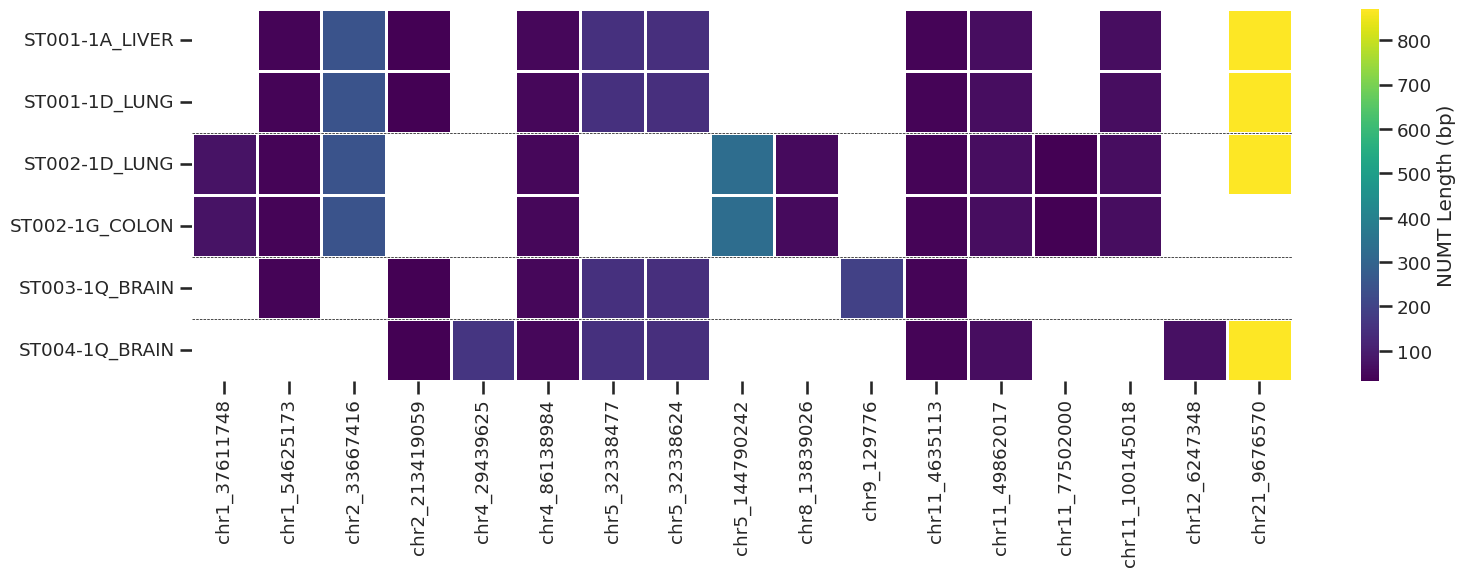

In [12]:

collapsed_numt_df[['nchr', 'npos_rep', 'length_rep2', 'mstart_rep', 'mend_rep']] = collapsed_numt_df['numt_long'].str.split('_', expand=True)
collapsed_numt_df['numt_short'] = collapsed_numt_df['nchr'] + "_" + collapsed_numt_df['npos_rep']

# Build column order by chromosome → position
collapsed_numt_df['chr_num'] = (
    collapsed_numt_df['nchr']
    .str.replace('chr', '', regex=False)
    .replace({'X': 23, 'Y': 24, 'M': 25})
    .astype(int)
)

collapsed_numt_df['npos_rep'] = collapsed_numt_df['npos_rep'].astype(int)

column_order = (
    collapsed_numt_df[['numt_short', 'chr_num', 'npos_rep']]
    .drop_duplicates()
    .sort_values(['chr_num', 'npos_rep'])
    ['numt_short']
)

heatmap_data = collapsed_numt_df.pivot(index=['Donor_Tissue'], columns='numt_short', values='length_rep')
heatmap_data = heatmap_data[column_order]

sns.set_theme(style="ticks", context="talk", font_scale=0.8)
plt.figure(figsize=(16, 6))

ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    linewidths=1,
    annot=False,
    cbar_kws={'label': 'NUMT Length (bp)'}
)

row_labels = heatmap_data.index.to_list()
donors = [x.split('-')[0] for x in row_labels]

boundary_positions = [
    i for i in range(1, len(donors))
    if donors[i] != donors[i - 1]
]

for y in boundary_positions:
    ax.hlines(y, *ax.get_xlim(), colors='black', linewidth=0.5,  linestyles='dashed')

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()



In [13]:
# count unique samples per NUMT_ID
freq_df = (
    collapsed_numt_df.groupby("numt_long")["Donor_Tissue"]
      .nunique()
      .reset_index(name="freq")
)

collapsed_numt_df = collapsed_numt_df.merge(freq_df, on="numt_long")
collapsed_numt_df

,numt_long,length_rep,Donor,Tissue,reps,rep_names,Donor_Tissue,nchr,npos_rep,length_rep2,mstart_rep,mend_rep,numt_short,chr_num,freq
0,chr11_100145018_59_11499_11557,59,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-uwsc,ST001-1A_LIVER-pacb...",ST001-1A_LIVER,chr11,100145018,59,11499,11557,chr11_100145018,11,4
1,chr11_100145018_59_11499_11557,59,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG,chr11,100145018,59,11499,11557,chr11_100145018,11,4
2,chr11_100145018_59_11499_11557,59,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG,chr11,100145018,59,11499,11557,chr11_100145018,11,4
3,chr11_100145018_59_11499_11557,59,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",ST002-1G_COLON,chr11,100145018,59,11499,11557,chr11_100145018,11,4
4,chr11_4635113_40_16423_16462,40,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-uwsc,ST001-1A_LIVER-pacb...",ST001-1A_LIVER,chr11,4635113,40,16423,16462,chr11_4635113,11,6
5,chr11_4635113_40_16423_16462,40,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG,chr11,4635113,40,16423,16462,chr11_4635113,11,6
6,chr11_4635113_40_16423_16462,40,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG,chr11,4635113,40,16423,16462,chr11_4635113,11,6
7,chr11_4635113_40_16423_16462,40,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",ST002-1G_COLON,chr11,4635113,40,16423,16462,chr11_4635113,11,6
8,chr11_4635113_40_16423_16462,40,ST003,1Q_BRAIN,6,"ST003-1Q_BRAIN-pacbio-washu,ST003-1Q_BRAIN-pac...",ST003-1Q_BRAIN,chr11,4635113,40,16423,16462,chr11_4635113,11,6
9,chr11_4635113_40_16423_16462,40,ST004,1Q_BRAIN,6,"ST004-1Q_BRAIN-pacbio-uwsc,ST004-1Q_BRAIN-pacb...",ST004-1Q_BRAIN,chr11,4635113,40,16423,16462,chr11_4635113,11,6


In [14]:
norm = colors.Normalize(
    vmin=collapsed_numt_df["freq"].min(),
    vmax=collapsed_numt_df["freq"].max()
)

cmap = cm.viridis   # blue → green → yellow

In [15]:
## circos plot 

from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_eukaryote_example_dataset

mt_length = 16569 
scale_factor=200000
bed_file = "/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/circos.bed"

# Initialize Circos with space between chromosomes
circos = Circos.initialize_from_bed(bed_file, space=2)

# Assign Colors
chr_names = [s.name for s in circos.sectors]

#ColorCycler.set_cmap("gist_rainbow")
colors = ColorCycler.get_color_list(len(chr_names))
colors = list(plt.cm.tab20(np.linspace(0, 1, 20)))  # 20 colors
colors += list(plt.cm.tab20b(np.linspace(0, 1, 4)))  # 4 more colors
chr_name2color = {name: color for name, color in zip(chr_names, colors)}
#chr_name2color = {name: colors[i % 24] for i, name in enumerate(chr_names)}

#---- Label chromosomes and draw outer track ----
tick_interval = 2000
positions = [i * scale_factor for i in range(0, mt_length, tick_interval)]
labels = [f"{i//1000}k" for i in range(0, mt_length, tick_interval)]

for sector in circos.sectors:
    label = sector.name.replace("chr", "")
    sector.text(label, size=10)
    track = sector.add_track((95, 100))

    if sector.name in ["chrM", "chrMT"]:
        track.xticks(
            positions,
            labels=labels,
            outer=True,
            label_orientation="vertical"
        )
        track.axis(fc="#6baed6", lw=1)
    else:
        color = chr_name2color.get(sector.name, "gray")
        track.axis(fc=color, lw=1)

collapsed_numt_df['mstart_rep'] = collapsed_numt_df['mstart_rep'].astype(int)
collapsed_numt_df['mend_rep'] = collapsed_numt_df['mend_rep'].astype(int)

# ---- Plot each link ----
for _, row in collapsed_numt_df.iterrows():
    region_mt = ("chrMT", int(row["mstart_rep"]*scale_factor), int(row["mend_rep"]*scale_factor))
    region_nuc = (row["nchr"], int(row["npos_rep"]), int(row["npos_rep"] + 1))
    # Color based on nuclear chromosome
   # color = chr_name2color.get(row["nchr"], "blue")
    color = cmap(norm(row["freq"]))

    circos.link(region_mt, region_nuc, color=color, alpha=0.8, lw=0.5)

# ---- Save ----
circos.savefig('circos.png', dpi=300)


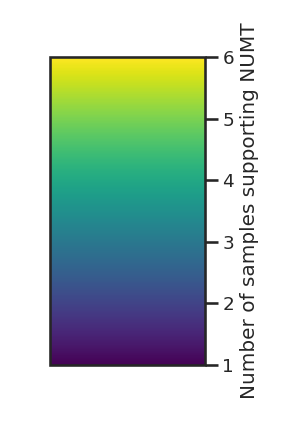

In [16]:
import matplotlib.pyplot as plt
from matplotlib import cm

# define colormap and normalization
cmap = cm.viridis
norm = plt.Normalize(vmin=collapsed_numt_df["freq"].min(),
                     vmax=collapsed_numt_df["freq"].max())

# create a dummy figure just for the colorbar
fig, ax = plt.subplots(figsize=(2, 4))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax)
cbar.set_label("Number of samples supporting NUMT")
fig.savefig("colorbar.png", dpi=300, bbox_inches="tight")


In [17]:

seqfirst_numt_df = pd.DataFrame()


seqfirst_pb_samples = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/pacbio/samples_for_merge_pb.csv')
for i in range(0, len(seqfirst_pb_samples)):
    row = seqfirst_pb_samples.iloc[i]
    sample = row['sample']
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    numt_df['Family_ID_Member'] = row['family_id_member']
    numt_df['Seq_Tech'] = 'pacbio'
    seqfirst_numt_df = pd.concat([seqfirst_numt_df, numt_df])

seqfirst_ont_samples = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/ont/samples_for_merge_ont.csv')
for i in range(0, len(seqfirst_ont_samples)):
    row = seqfirst_ont_samples.iloc[i]
    sample = row['sample']
    if sample != '-':
        file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
        numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
        numt_df['Sample'] = sample
        numt_df['Family_ID_Member'] = row['family_id_member']
        numt_df['Seq_Tech'] = 'ont'
        seqfirst_numt_df = pd.concat([seqfirst_numt_df, numt_df])


seqfirst_numt_df[['nchr', 'npos']] = seqfirst_numt_df['qseqid'].str.split('-', expand=True)
seqfirst_numt_df['npos'] = np.where(seqfirst_numt_df['qstart'].astype(int) > 1, seqfirst_numt_df['npos'].astype(int) + seqfirst_numt_df['qstart'].astype(int) - 1, seqfirst_numt_df['npos'].astype(int))
seqfirst_numt_df['id'] = seqfirst_numt_df['nchr'] + "-" + seqfirst_numt_df['npos'].astype(str)
seqfirst_numt_df = seqfirst_numt_df[seqfirst_numt_df['nchr'] != 'chrM']
seqfirst_numt_df['mstart'] = np.where(seqfirst_numt_df['sstart'].astype(int) < seqfirst_numt_df['send'].astype(int), seqfirst_numt_df['sstart'].astype(int), seqfirst_numt_df['send'].astype(int))
seqfirst_numt_df['mend'] = np.where(seqfirst_numt_df['sstart'].astype(int) >= seqfirst_numt_df['send'].astype(int), seqfirst_numt_df['sstart'].astype(int), seqfirst_numt_df['send'].astype(int))

seqfirst_numt_df = seqfirst_numt_df[['qseqid', 'id', 'nchr', 'npos', 'length', 'mstart', 'mend', 'Sample', 'Family_ID_Member', 'Seq_Tech']]

seqfirst_numt_df



,qseqid,id,nchr,npos,length,mstart,mend,Sample,Family_ID_Member,Seq_Tech
0,chr1-54625173,chr1-54625173,chr1,54625173,41,1573,1613,1689232,K49199_Proband,pacbio
1,chr2-213419058,chr2-213419059,chr2,213419059,35,15066,15100,1689232,K49199_Proband,pacbio
2,chr4-86138984,chr4-86138984,chr4,86138984,47,6170,6216,1689232,K49199_Proband,pacbio
3,chr5-32338477,chr5-32338477,chr5,32338477,147,14831,14977,1689232,K49199_Proband,pacbio
4,chr5-32338477,chr5-32338624,chr5,32338624,145,12723,12867,1689232,K49199_Proband,pacbio
...,...,...,...,...,...,...,...,...,...,...
5,chr11-4635113,chr11-4635113,chr11,4635113,40,16423,16462,1647125,K49871_Father,ont
6,chr11-49862017,chr11-49862017,chr11,49862017,60,1,60,1647125,K49871_Father,ont
7,chr15-57433966,chr15-57433970,chr15,57433970,38,1906,1943,1647125,K49871_Father,ont
8,chr20-21474595,chr20-21478856,chr20,21478856,9545,1,9526,1647125,K49871_Father,ont


In [18]:
p = pd.merge(seqfirst_pb_samples, seqfirst_ont_samples, on='family_id_member')
pp = p[p['sample_y'] == '-']

#pp.columns = ['family_id_member', 'pb', 'ont']

only_1_seqtech = pp['family_id_member']
only_1_seqtech

94     K49634_Proband
95      K49634_Mother
96      K49634_Father
138     K49663_Mother
139     K49663_Father
190     K49730_Father
233     K49747_Mother
237    K50009_Proband
238     K50009_Mother
251     K49785_Father
256     K49771_Mother
293    K49210_Proband
294     K49210_Mother
295     K49210_Father
325    K49642_Proband
326     K49642_Mother
327     K49642_Father
332     K49850_Mother
Name: family_id_member, dtype: object

In [19]:

tolerance = 25

df = seqfirst_numt_df.sort_values(
    ['nchr', 'npos', 'mstart', 'mend']
).reset_index(drop=True)

numt_ids = [None] * len(df)
current_id = 1

for i in range(len(df)):
    if numt_ids[i] is not None:
        continue

    numt_ids[i] = f"NUMT_{current_id}"
    current = df.iloc[i]

    # grow cluster forward
    for j in range(i + 1, len(df)):
        row = df.iloc[j]

        if row['nchr'] != current['nchr']:
            break  # sorted by chr

        if abs(row['npos'] - current['npos']) > tolerance:
            break  # window exceeded

        if (
            abs(row['length'] - current['length']) <= tolerance and
            abs(row['mstart'] - current['mstart']) <= tolerance and
            abs(row['mend'] - current['mend']) <= tolerance
        ):
            numt_ids[j] = f"NUMT_{current_id}"

    current_id += 1

df['NUMT_ID'] = numt_ids

rep_cols = {
    'npos':   'npos_rep',
    'length':'length_rep',
    'mstart':'mstart_rep',
    'mend':  'mend_rep'
}

for col, new_col in rep_cols.items():
    df[new_col] = (
        df.groupby('NUMT_ID')[col]
          .transform('median')
          .astype(int)
    )

df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)


seqfirst_numt_df_collapsed = df.copy()
seqfirst_numt_df_collapsed

,qseqid,id,nchr,npos,length,mstart,mend,Sample,Family_ID_Member,Seq_Tech,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
0,chr1-2915460,chr1-2915461,chr1,2915461,69,6784,6852,1689475,K49747_Mother,pacbio,NUMT_1,2915461,69,6784,6852,chr1_2915461_69_6784_6852
1,chr1-8015743,chr1-8015743,chr1,8015743,77,7738,7814,1689558,K49844_Proband,pacbio,NUMT_2,8015743,77,7738,7814,chr1_8015743_77_7738_7814
2,chr1-8015743,chr1-8015743,chr1,8015743,77,7738,7814,1689559,K49844_Mother,pacbio,NUMT_2,8015743,77,7738,7814,chr1_8015743_77_7738_7814
3,chr1-8015743,chr1-8015743,chr1,8015743,77,7738,7814,1642862,K49844_Proband,ont,NUMT_2,8015743,77,7738,7814,chr1_8015743_77_7738_7814
4,chr1-8015743,chr1-8015743,chr1,8015743,77,7738,7814,1642863,K49844_Mother,ont,NUMT_2,8015743,77,7738,7814,chr1_8015743_77_7738_7814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6409,chrX-46487737,chrX-46487739,chrX,46487739,283,914,1196,1689247,K49220_Father,pacbio,NUMT_178,46487739,283,914,1196,chrX_46487739_283_914_1196
6410,chrX-46487737,chrX-46487739,chrX,46487739,283,914,1196,1645705,K49220_Father,ont,NUMT_178,46487739,283,914,1196,chrX_46487739_283_914_1196
6411,chrX-116850352,chrX-116850352,chrX,116850352,5600,10495,16091,1689402,K49684_Father,pacbio,NUMT_179,116850352,5600,10495,16091,chrX_116850352_5600_10495_16091
6412,chrX-116850352,chrX-116854781,chrX,116854781,2032,3642,5657,1650892,K49684_Father,ont,NUMT_180,116854781,2032,3642,5657,chrX_116854781_2032_3642_5657


In [20]:
t = seqfirst_numt_df_collapsed.groupby(['numt_long','Family_ID_Member']).agg(reps=('numt_long', 'count')).reset_index()
t.groupby(['reps']).count()

#t[t['Family_ID_Member'].isin(only_1_seqtech)]

# total calls = 3583
# pb&ont = 2831 (79%)
# 1tech_bc_missing = 183 (5%)
# 1tech_bc_notcalled = 569 (16%)

,numt_long,Family_ID_Member
reps,,
1,752,752
2,2831,2831


In [21]:
total_seqfirst_samples = t['Family_ID_Member'].nunique()

seqfirst_PAFs = t.groupby('numt_long').agg(sample_count=('Family_ID_Member', 'count')).reset_index()
seqfirst_PAFs['PAF'] = seqfirst_PAFs['sample_count'] / total_seqfirst_samples

conditions = [
    (seqfirst_PAFs['PAF'] >= 0.1),
    (seqfirst_PAFs['PAF'] >= 0.01),
    (seqfirst_PAFs['PAF'] < 0.01)
]
choices = ['Common', 'Rare', 'Ultra-rare']

seqfirst_PAFs['Frequency_Group'] = np.select(conditions, choices, default='Unknown')

seqfirst_PAFs['Frequency_Group'].value_counts()

#seqfirst_PAFs


Frequency_Group
Ultra-rare    130
Rare           36
Common         15
Name: count, dtype: int64

In [22]:
gen_england_db = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/downloadGermline.txt')
gen_england_db

gen_england_db['Frequency_group'].value_counts()

Frequency_group
ultra-rare    1567
rare            49
common          21
Name: count, dtype: int64

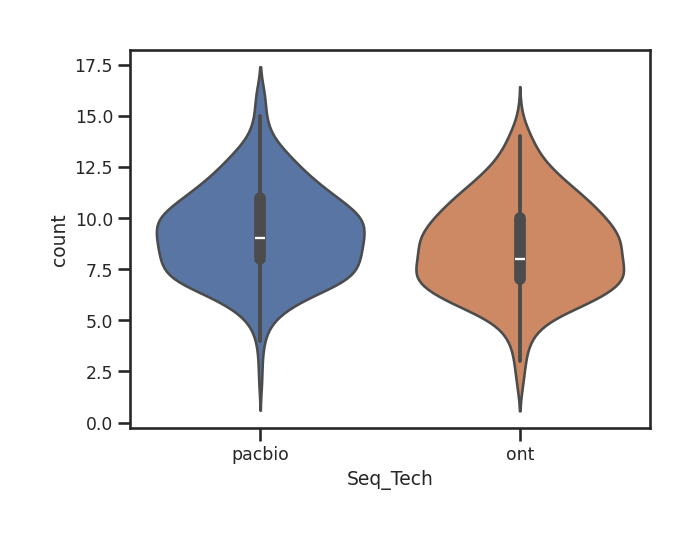

In [23]:
counts_seqfirst = (
    seqfirst_numt_df_collapsed.groupby(["Sample", "Seq_Tech"], as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)

counts_seqfirst

sns.set_theme(style="ticks", context="talk", font_scale=0.75)

sns.violinplot(
    data=counts_seqfirst,
    x="Seq_Tech",
    y="count",
    hue="Seq_Tech"
 #   kind="strip",
 #   height=4,
 #   aspect=0.8,
  #  palette="muted",
)

plt.tight_layout()
plt.show()



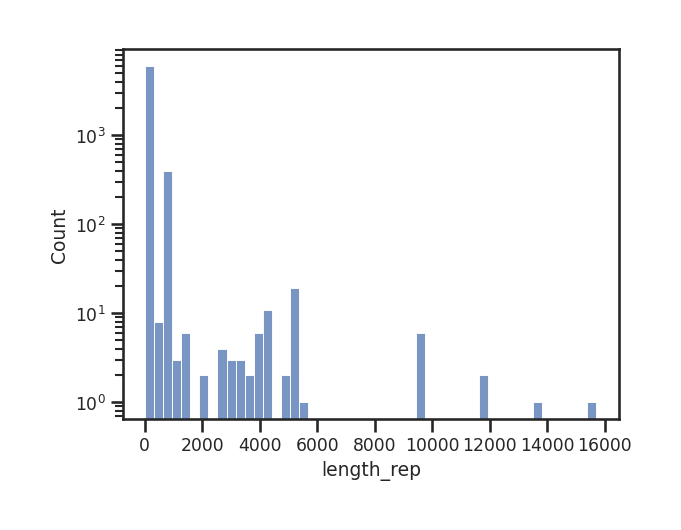

In [24]:
sns.histplot(seqfirst_numt_df_collapsed, x='length_rep', bins=50)
plt.yscale('log')

In [25]:
chromosomes = [f'chr{x}' for x in list(range(1, 22)) + ['X', 'Y']]

unique_numts = seqfirst_numt_df_collapsed[['numt_long', 'nchr', 'npos_rep', 'length_rep', 'mstart_rep', 'mend_rep']].drop_duplicates().reset_index()
unique_numts = unique_numts.drop(columns=['index'])
unique_numts = unique_numts[unique_numts['nchr'].isin(chromosomes)]
unique_numts['nchr'].value_counts()

nchr
chr7     17
chr1     15
chr6     14
chr11    14
chr4     12
chr20    10
chr3     10
chr2     10
chr5     10
chr12     9
chr8      9
chr9      7
chr13     7
chr21     6
chrX      6
chr10     5
chr14     5
chr15     4
chr18     4
chr19     2
chr16     2
chr17     2
Name: count, dtype: int64

In [26]:
seqfirst_unique_numts = pd.merge(unique_numts, seqfirst_PAFs, on='numt_long', how='left')

seqfirst_unique_numts

,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,sample_count,PAF,Frequency_Group
0,chr1_2915461_69_6784_6852,chr1,2915461,69,6784,6852,1,0.002653,Ultra-rare
1,chr1_8015743_77_7738_7814,chr1,8015743,77,7738,7814,2,0.005305,Ultra-rare
2,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,107,0.283820,Common
3,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613,192,0.509284,Common
4,chr1_59195881_57_15422_15478,chr1,59195881,57,15422,15478,29,0.076923,Rare
...,...,...,...,...,...,...,...,...,...
175,chrX_7997344_51_258_308,chrX,7997344,51,258,308,2,0.005305,Ultra-rare
176,chrX_46487739_283_914_1196,chrX,46487739,283,914,1196,1,0.002653,Ultra-rare
177,chrX_116850352_5600_10495_16091,chrX,116850352,5600,10495,16091,1,0.002653,Ultra-rare
178,chrX_116854781_2032_3642_5657,chrX,116854781,2032,3642,5657,1,0.002653,Ultra-rare


In [27]:


benchmarking_unique_numts = collapsed_numt_df[['numt_long', 'nchr', 'npos_rep', 'length_rep', 'mstart_rep', 'mend_rep']].drop_duplicates().reset_index()
benchmarking_unique_numts

# merge by chromosome first
merged = benchmarking_unique_numts.merge(gen_england_db, left_on="nchr", right_on="chromosome",  how="left", suffixes=("", "_db"))
merged
TOL = 50

merged["bp_ok"] = (
    ((abs(merged["nuclearGenome_breakpoint1"] - TOL)) < merged["npos_rep"]) & ((abs(merged["nuclearGenome_breakpoint2"] + TOL)) > merged["npos_rep"]))


merged[merged['bp_ok'] == True].sort_values('numt_long')

,index,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,numtID,chromosome,nuclearGenome_breakpoint1,nuclearGenome_breakpoint2,mtDNAGenome_breakpoint1,mtDNAGenome_breakpoint2,Frequency_group,longRead_validation,concatenatedNUMTs,Ethnicity,bp_ok
58,0,chr11_100145018_59_11499_11557,chr11,100145018,59,11499,11557,g1099,chr11,100145004,100145018,11498,11557.0,ultra-rare,Na,NCC,European,True
182,10,chr11_49862017_60_1_60,chr11,49862017,60,1,60,g1073,chr11,49862015,49862020,61,16088.0,common,Y,NCC,"African, American, EastAsian, SouthAsian, Euro...",True
304,17,chr12_6247348_66_12160_12225,chr12,6247348,66,12160,12225,g1120,chr12,6247321,6247322,12157,12225.0,common,Y,NCC,"African, American, SouthAsian, European",True
415,18,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,g20,chr1,37611748,37611748,8933,9007.0,common,Y,NCC,"African, American, EastAsian, SouthAsian, Euro...",True
637,25,chr21_9676570_870_12358_13227,chr21,9676570,870,12358,13227,g1545,chr21,9676162,9677122,12360,13227.0,common,Y,NCC,"African, American, EastAsian, SouthAsian, Euro...",True
792,29,chr2_213419059_35_15066_15100,chr2,213419059,35,15066,15100,g259,chr2,213419058,213419059,15065,15101.0,rare,Na,NCC,"SouthAsian, European",True
831,33,chr2_33667416_246_14777_15022,chr2,33667416,246,14777,15022,g151,chr2,33667411,33667416,14776,15022.0,common,Y,NCC,"African, American, EastAsian, SouthAsian, Euro...",True
975,37,chr4_29439625_162_12835_12996,chr4,29439625,162,12835,12996,g422,chr4,29439625,29439625,12834,12997.0,common,Y,NCC,"African, American, EastAsian, SouthAsian, Euro...",True
1108,38,chr4_86138984_47_6170_6216,chr4,86138984,47,6170,6216,g447,chr4,86138985,86138999,6147,6217.0,ultra-rare,Na,NCC,"African, American, SouthAsian, European",True
1269,44,chr5_144790242_329_15178_15506,chr5,144790242,329,15178,15506,g608,chr5,144790240,144790245,15177,15510.0,common,Y,NCC,"African, American, SouthAsian, European",True


In [28]:
# merge by chromosome first
seqfirst_merged = unique_numts.merge(gen_england_db, left_on="nchr", right_on="chromosome",  how="left", suffixes=("", "_db"))
TOL = 100

seqfirst_merged["bp_ok"] = (
    ((abs(seqfirst_merged["nuclearGenome_breakpoint1"] - TOL)) < seqfirst_merged["npos_rep"]) & ((abs(seqfirst_merged["nuclearGenome_breakpoint2"] + TOL)) > seqfirst_merged["npos_rep"]))


seqfirst_merged['diff'] = abs(seqfirst_merged['npos_rep'] - seqfirst_merged['nuclearGenome_breakpoint1'])

seqfirst_merged[seqfirst_merged['bp_ok'] == True]['numt_long'].nunique()


79

In [29]:
# merge by chromosome first
benchmark_seqfirst_merged = benchmarking_unique_numts.merge(seqfirst_unique_numts, on="nchr",  how="left", suffixes=("", "_db"))

TOL = 50

benchmark_seqfirst_merged["bp_ok"] = (
    (abs(benchmark_seqfirst_merged["npos_rep"] - benchmark_seqfirst_merged["npos_rep_db"]) < TOL ))


benchmark_seqfirst_merged = benchmark_seqfirst_merged[benchmark_seqfirst_merged['bp_ok'] == True].sort_values('numt_long')

benchmark_seqfirst_merged

,index,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,numt_long_db,npos_rep_db,length_rep_db,mstart_rep_db,mend_rep_db,sample_count,PAF,Frequency_Group,bp_ok
10,0,chr11_100145018_59_11499_11557,chr11,100145018,59,11499,11557,chr11_100145018_59_11499_11557,100145018,59,11499,11557,76,0.201592,Common,True
15,4,chr11_4635113_40_16423_16462,chr11,4635113,40,16423,16462,chr11_4635113_40_16423_16462,4635113,40,16423,16462,373,0.989390,Common,True
32,10,chr11_49862017_60_1_60,chr11,49862017,60,1,60,chr11_49862017_60_1_60,49862017,60,1,60,317,0.840849,Common,True
47,15,chr11_77502000_32_13648_13679,chr11,77502000,32,13648,13679,chr11_77502000_32_13648_13679,77502000,32,13648,13679,122,0.323607,Common,True
56,17,chr12_6247348_66_12160_12225,chr12,6247348,66,12160,12225,chr12_6247348_66_12160_12225,6247348,66,12160,12225,30,0.079576,Rare,True
67,18,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,chr1_37611748_72_8935_9006,37611748,72,8935,9006,107,0.283820,Common,True
83,20,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613,chr1_54625173_41_1573_1613,54625173,41,1573,1613,192,0.509284,Common,True
96,25,chr21_9676570_870_12358_13227,chr21,9676570,870,12358,13227,chr21_9676570_870_12358_13227,9676570,870,12358,13227,222,0.588859,Common,True
95,25,chr21_9676570_870_12358_13227,chr21,9676570,870,12358,13227,chr21_9676570_879_12358_13227,9676570,879,12358,13227,11,0.029178,Rare,True
107,29,chr2_213419059_35_15066_15100,chr2,213419059,35,15066,15100,chr2_213419059_35_15066_15100,213419059,35,15066,15100,146,0.387268,Common,True


In [30]:
benchmarking_unique_numts

,index,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep
0,0,chr11_100145018_59_11499_11557,chr11,100145018,59,11499,11557
1,4,chr11_4635113_40_16423_16462,chr11,4635113,40,16423,16462
2,10,chr11_49862017_60_1_60,chr11,49862017,60,1,60
3,15,chr11_77502000_32_13648_13679,chr11,77502000,32,13648,13679
4,17,chr12_6247348_66_12160_12225,chr12,6247348,66,12160,12225
5,18,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006
6,20,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613
7,25,chr21_9676570_870_12358_13227,chr21,9676570,870,12358,13227
8,29,chr2_213419059_35_15066_15100,chr2,213419059,35,15066,15100
9,33,chr2_33667416_246_14777_15022,chr2,33667416,246,14777,15022


In [31]:
seqfirst_unique_numts

,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,sample_count,PAF,Frequency_Group
0,chr1_2915461_69_6784_6852,chr1,2915461,69,6784,6852,1,0.002653,Ultra-rare
1,chr1_8015743_77_7738_7814,chr1,8015743,77,7738,7814,2,0.005305,Ultra-rare
2,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,107,0.283820,Common
3,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613,192,0.509284,Common
4,chr1_59195881_57_15422_15478,chr1,59195881,57,15422,15478,29,0.076923,Rare
...,...,...,...,...,...,...,...,...,...
175,chrX_7997344_51_258_308,chrX,7997344,51,258,308,2,0.005305,Ultra-rare
176,chrX_46487739_283_914_1196,chrX,46487739,283,914,1196,1,0.002653,Ultra-rare
177,chrX_116850352_5600_10495_16091,chrX,116850352,5600,10495,16091,1,0.002653,Ultra-rare
178,chrX_116854781_2032_3642_5657,chrX,116854781,2032,3642,5657,1,0.002653,Ultra-rare


In [32]:
## circos plot 

from pycirclize import Circos
from pycirclize.utils import ColorCycler

mt_length = 16569 
scale_factor=200000
bed_file = "/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/circos.bed"

# Initialize Circos with space between chromosomes
circos = Circos.initialize_from_bed(bed_file, space=2)

# Assign Colors
chr_names = [s.name for s in circos.sectors]

#ColorCycler.set_cmap("gist_rainbow")
colors = ColorCycler.get_color_list(len(chr_names))
colors = list(plt.cm.tab20(np.linspace(0, 1, 20)))  # 20 colors
colors += list(plt.cm.tab20b(np.linspace(0, 1, 4)))  # 4 more colors
chr_name2color = {name: color for name, color in zip(chr_names, colors)}
#chr_name2color = {name: colors[i % 24] for i, name in enumerate(chr_names)}

#---- Label chromosomes and draw outer track ----
tick_interval = 2000
positions = [i * scale_factor for i in range(0, mt_length, tick_interval)]
labels = [f"{i//1000}k" for i in range(0, mt_length, tick_interval)]

for sector in circos.sectors:
    label = sector.name.replace("chr", "")
    sector.text(label, size=10)
    track = sector.add_track((95, 100))

    if sector.name in ["chrM", "chrMT"]:
        track.xticks(
            positions,
            labels=labels,
            outer=True,
            label_orientation="vertical"
        )
        track.axis(fc="#6baed6", lw=1)
    else:
        color = chr_name2color.get(sector.name, "gray")
        track.axis(fc=color, lw=1)


benchmark_seqfirst_merged['mstart_rep'] = benchmark_seqfirst_merged['mstart_rep'].astype(int)
benchmark_seqfirst_merged['mend_rep'] = benchmark_seqfirst_merged['mend_rep'].astype(int)


norm = matplotlib.colors.Normalize(
    vmin=benchmark_seqfirst_merged["PAF"].min(),
    vmax=benchmark_seqfirst_merged["PAF"].max()
)

cmap = cm.viridis
# ---- Plot each link ----
for _, row in benchmark_seqfirst_merged.iterrows():
    region_mt = ("chrMT", int(row["mstart_rep"]*scale_factor), int(row["mend_rep"]*scale_factor))
    region_nuc = (row["nchr"], int(row["npos_rep"]), int(row["npos_rep"] + 1))
    # Color based on nuclear chromosome
   # color = chr_name2color.get(row["nchr"], "blue")
    color = cmap(norm(row["PAF"]))

    circos.link(region_mt, region_nuc, color=color, alpha=0.8, lw=0.5)

# ---- Save ----
circos.savefig('circos2.png', dpi=300)


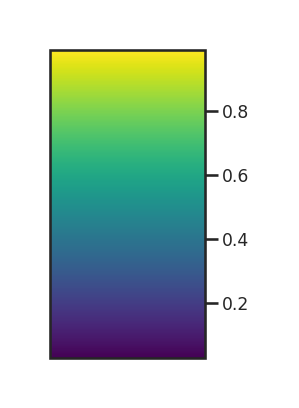

In [33]:

# define colormap and normalization
cmap = cm.viridis
norm = plt.Normalize(vmin=benchmark_seqfirst_merged["PAF"].min(),
                     vmax=benchmark_seqfirst_merged["PAF"].max())

# create a dummy figure just for the colorbar
fig, ax = plt.subplots(figsize=(2, 4))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax)
#cbar.set_label("Number of samples supporting NUMT")
fig.savefig("colorbar.png", dpi=300, bbox_inches="tight")
